# Recipe Project

**Name(s)**: Ryan Lindberg

**Website Link**: lindbergryan04.github.io/reponame

In [1]:
import os
from pathlib import Path
import ast

import numpy as np
import pandas as pd
pd.options.plotting.backend = 'plotly'

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import pearsonr

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import f_classif, RFE
from sklearn.metrics import accuracy_score, classification_report

from dsc80_utils import *

## Step 1: Introduction

In [7]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [12]:
food_data = pd.read_csv('data/RAW_recipes.csv')
#print(food_data)
interactions_data = pd.read_csv('data/RAW_interactions.csv')
interactions_data['recipe_id'] = interactions_data['recipe_id'].astype(int)
recipes = food_data.merge(interactions_data, how = 'left', right_on = 'recipe_id', left_on = 'id')
#print(recipes.columns)
recipes = recipes.set_index('id').drop(columns = ['recipe_id'])

In [13]:
recipes

,name,minutes,contributor_id,submitted,...,user_id,date,rating,review
id,,,,,,,,,
333281,1 brownies in the world best ever,40,985201,2008-10-27,...,386585.00,2008-11-19,4.00,"These were pretty good, but took forever to ba..."
453467,1 in canada chocolate chip cookies,45,1848091,2011-04-11,...,424680.00,2012-01-26,5.00,Originally I was gonna cut the recipe in half ...
306168,412 broccoli casserole,40,50969,2008-05-30,...,29782.00,2008-12-31,5.00,This was one of the best broccoli casseroles t...
306168,412 broccoli casserole,40,50969,2008-05-30,...,1196280.00,2009-04-13,5.00,I made this for my son's first birthday party ...
306168,412 broccoli casserole,40,50969,2008-05-30,...,768828.00,2013-08-02,5.00,Loved this. Be sure to completely thaw the br...
...,...,...,...,...,...,...,...,...,...
308080,zydeco ya ya deviled eggs,40,37779,2008-06-07,...,844554.00,2009-10-14,5.00,These were very good. I meant to add some jala...
298512,cookies by design cookies on a stick,29,506822,2008-04-15,...,804234.00,2008-05-02,1.00,I would rate this a zero if I could. I followe...
298509,cookies by design sugar shortbread cookies,20,506822,2008-04-15,...,866651.00,2008-06-19,1.00,This recipe tastes nothing like the Cookies by...


## Understanding the Data

| Column            | Description                                                         | Unique Values or Range |
|------------------|---------------------------------------------------------------------|------------------------|
| `'id'`           | Recipe ID                                                          | Unique ID values       |
| `'name'`         | Recipe name                                                        | Various text values    |
| `'minutes'`      | Minutes required to prepare the recipe                            | Varies (integer)       |
| `'contributor_id'` | User ID who submitted the recipe                                 | Unique ID values       |
| `'submitted'`    | Date the recipe was submitted                                     | YYYY-MM-DD format      |
| `'tags'`         | Food.com tags associated with the recipe                          | List of text values    |
| `'nutrition'`    | Nutrition information `[calories (#), total fat (PDV), sugar (PDV), sodium (PDV), protein (PDV), saturated fat (PDV), carbohydrates (PDV)]` | List of numerical values |
| `'n_steps'`      | Number of steps in the recipe                                    | Integer                |
| `'steps'`        | Text for the recipe steps, in order                              | List of text values    |
| `'description'`  | User-provided description of the recipe                          | Text                   |
| `'user_id'`      | ID of the user who interacted with the recipe                    | Unique ID values       |
| `'date'`         | Date of the interaction                                          | YYYY-MM-DD format      |
| `'rating'`       | Rating given in the interaction                                  | Integer (1-5)          |
| `'review'`       | Review text from the interaction                                | Text                   |



**Note:** Not all recipes have ratings due to the left merge, so some rows may have missing values for user_id, date, rating, and review.

### Possible Questions:

**1.** What types of recipes tend to be healthier (i.e. more protein, fewer carbs)?

**2.** What types of recipes tend to have higher average ratings?

**3.** What is the relationship between the number of steps and rating of recipes?

**4.** What is the relationship between nutritional metrics (e.g., calories, total fat, sugar) and user ratings?

**5.** Which recipes offer the best balance between healthiness, quick preparation, and taste?

**Motivation:**

Since Ethan and I have transferred to UCSD, our cooking has devolved to become a bit less healthy due to lack of food access and lack of time. We're curious about what ingredients/recipes we could  use to help us fix this issue. Ideally these recipes are cost effective in terms of time and money, and use simple ingredients. Also, the food should be tasty of course!

We think **Question #5** will be the best to help us solve our predicament. 

## Step 2: Data Cleaning and Exploratory Data Analysis

### Cleaning

Replace 0 ratings with np.nan:

In [14]:
recipes['rating'] = recipes['rating'].replace(0, np.nan)

Add avg_rating column (avg rating for each recipe):

In [15]:
recipes['avg_rating'] = recipes.groupby('id')['rating'].transform('mean')

Remove unnecessary columns:

In [16]:
recipes = recipes.drop(columns = ['review','contributor_id','user_id','date','submitted','description','steps'])

Convert string lists to actual lists:

For example: The string "['60-minutes-or-less', 'time-to-make', 'course']" from tags column, or the string '[138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]' from nutrition column.

In [17]:
columns_to_convert = ['tags','nutrition','ingredients']  

for col in columns_to_convert:
    recipes[col] = recipes[col].apply(ast.literal_eval)

Parse nutrition lists into their own columns:

  `[calories (#), total fat (PDV), sugar (PDV), sodium (PDV), protein (PDV), saturated fat (PDV), carbohydrates (PDV)]`

In [18]:
recipes[[
    'calories',
    'total_fat',
    'sugar',
    'sodium',
    'protein',
    'sat_fat',
    'carbs'
]] = pd.DataFrame(recipes['nutrition'].tolist(), index=recipes.index)

In [19]:
recipes.columns

Index(['name', 'minutes', 'tags', 'nutrition', 'n_steps', 'ingredients',
       'n_ingredients', 'rating', 'avg_rating', 'calories', 'total_fat',
       'sugar', 'sodium', 'protein', 'sat_fat', 'carbs'],
      dtype='object')

In [20]:
recipes = recipes.drop(columns = ['nutrition'])

In [21]:
recipes_copy = recipes.copy()
recipes_copy = recipes_copy[~recipes_copy.index.duplicated(keep='first')]

In [359]:
recipes

,name,minutes,tags,n_steps,...,sodium,protein,sat_fat,carbs
id,,,,,,,,,
333281,1 brownies in the world best ever,40,"[60-minutes-or-less, time-to-make, course, mai...",10,...,3.00,3.00,19.00,6.00
453467,1 in canada chocolate chip cookies,45,"[60-minutes-or-less, time-to-make, cuisine, pr...",12,...,22.00,13.00,51.00,26.00
306168,412 broccoli casserole,40,"[60-minutes-or-less, time-to-make, course, mai...",6,...,32.00,22.00,36.00,3.00
306168,412 broccoli casserole,40,"[60-minutes-or-less, time-to-make, course, mai...",6,...,32.00,22.00,36.00,3.00
306168,412 broccoli casserole,40,"[60-minutes-or-less, time-to-make, course, mai...",6,...,32.00,22.00,36.00,3.00
...,...,...,...,...,...,...,...,...,...
308080,zydeco ya ya deviled eggs,40,"[60-minutes-or-less, time-to-make, course, mai...",7,...,3.00,6.00,5.00,0.00
298512,cookies by design cookies on a stick,29,"[30-minutes-or-less, time-to-make, course, pre...",9,...,11.00,7.00,21.00,9.00
298509,cookies by design sugar shortbread cookies,20,"[30-minutes-or-less, time-to-make, course, pre...",5,...,4.00,4.00,11.00,6.00


### Exploratory Analysis

In [118]:
eda_recipes = recipes.copy()

Lets look at the descriptive statistics of rating and prep time:

In [119]:
print(eda_recipes['minutes'].describe())
print(eda_recipes['avg_rating'].describe())

count    234429.00
mean        106.79
std        3285.97
min           0.00
25%          20.00
50%          35.00
75%          60.00
max     1051200.00
Name: minutes, dtype: float64
count   231652.00
mean         4.68
std          0.50
min          1.00
25%          4.50
50%          4.86
75%          5.00
max          5.00
Name: avg_rating, dtype: float64


The mean rating for all recipes is 4.65, which is oddly high. On a 1-10 scale thats equivalent to 9.3. Either the recipes in this dataset are very good, or the ratings are biased towards higher values. 

In [120]:
eda_recipes_sample = eda_recipes[eda_recipes['minutes'] < 200].sample(n=5000, random_state=0)

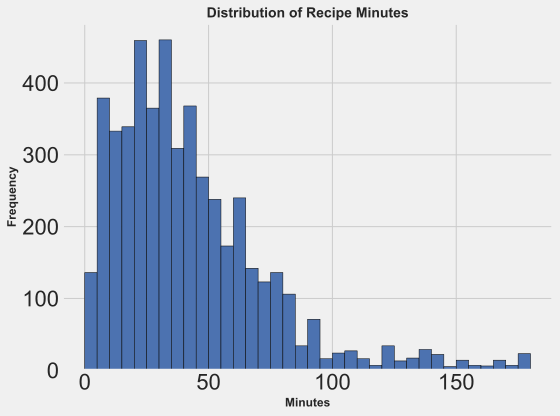

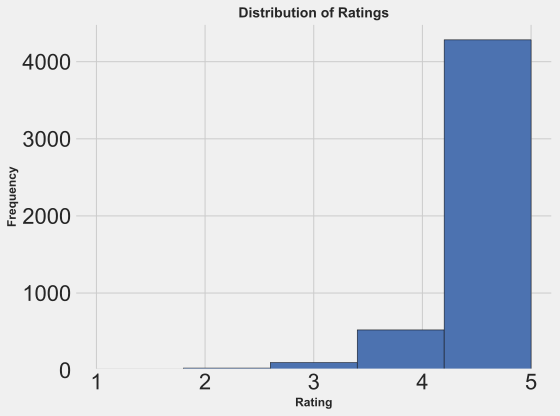

In [ ]:
plt.style.use('fivethirtyeight')

plt.figure(figsize=(8, 6))
plt.hist(eda_recipes_sample['minutes'], bins=np.arange(0, 185, 5),
         edgecolor='black', color='#4c72b0')  

plt.ticklabel_format(style='plain', axis='x')
plt.xlabel("Minutes", fontsize=12, fontweight='bold')
plt.ylabel("Frequency", fontsize=12, fontweight='bold')
plt.title("Distribution of Recipe Minutes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


plt.style.use('fivethirtyeight')

plt.figure(figsize=(8, 6))
plt.hist(eda_recipes_sample['avg_rating'], bins=5,
         edgecolor='black', color='#4c72b0')  

plt.ticklabel_format(style='plain', axis='x')
plt.xlabel("Rating", fontsize=12, fontweight='bold')
plt.ylabel("Frequency", fontsize=12, fontweight='bold')
plt.title("Distribution of Ratings", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Next, which numerical variables are most linearly correlated with rating?

In [122]:
eda_recipes_sample2 = eda_recipes.sample(n=5000, random_state=0)

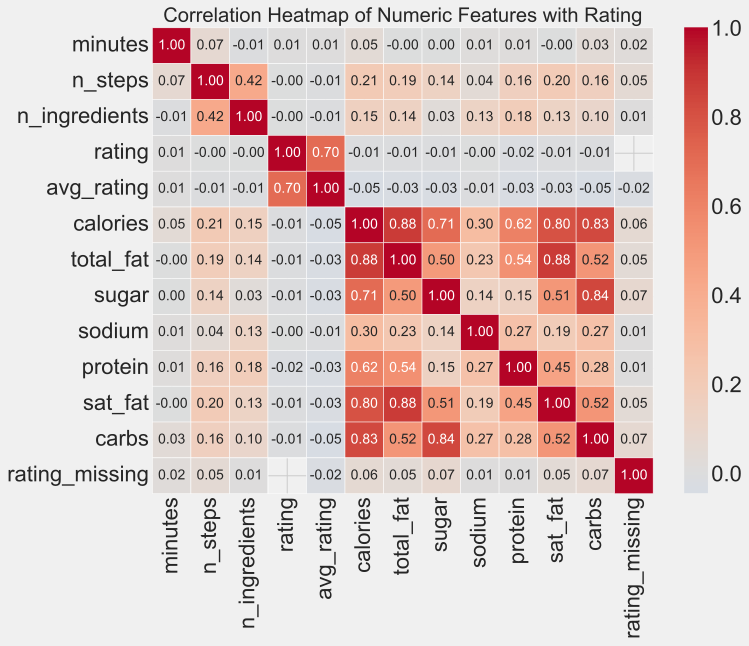

In [ ]:

# Create a binary column for rating missingness
eda_recipes_sample2['rating_missing'] = eda_recipes_sample2['rating'].isna().astype(int)

# Select only numeric columns (for correlation analysis)
numeric_cols = eda_recipes_sample2.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr_matrix = numeric_cols.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)

# Title and show
plt.title("Correlation Heatmap of Numeric Features with Rating")
plt.show()

It seems that no linear correlation between any numerical variable and avg_rating. My intuition would lead me to think maybe sugar and minutes or calories would have some association. Maybe there are hidden, perhaps non-linear relationships that we are not seeing.

Avg_rating is looking like it will be hard to predict. We will likely have to do further exploration and feature engineering to solve this.

Lets take a look at the pivot table of number of steps and avg rating to see if we an recognize any patterns.

In [108]:
# Ensure 'n_steps' and 'rating' are numeric
eda_recipes_sample2['n_steps'] = pd.to_numeric(eda_recipes_sample2['n_steps'], errors='coerce')
eda_recipes_sample2['rating'] = pd.to_numeric(eda_recipes_sample2['avg_rating'], errors='coerce')

# Create a pivot table that aggregates average rating and recipe count by number of steps
pivot_complexity = eda_recipes_sample2.pivot_table(index='n_steps', values='avg_rating', aggfunc=['mean', 'count'])
pivot_complexity.iloc[0:20]

,mean,count
,avg_rating,avg_rating
n_steps,,
1,4.60,77
2,4.66,155
3,4.65,268
4,4.62,289
5,4.61,390
6,4.57,368
7,4.59,416
8,4.61,380


Lets take a look at the scatter plots to investigate further.

In [ ]:
cols_to_scatter = [
    'calories',
    'total_fat',
    'sugar',
    'sodium',
    'protein',
    'sat_fat',
    'carbs',
    'n_steps',
    'minutes'
]

# 2) Melt the DataFrame from wide to long format
melted = eda_recipes_sample2.melt(
    id_vars='avg_rating',         
    value_vars=cols_to_scatter, 
    var_name='nutrient',      
    value_name='value'        
)
# 3) Use a relplot with facets
g = sns.relplot(
    data=melted,
    x='avg_rating', 
    y='value', 
    col='nutrient',       # create a separate subplot (facet) for each nutrient
    col_wrap=3,           # wrap into rows of 3 subplots
    kind='scatter',
    height=4, aspect=1.2, 
    alpha=0.5             
)
g.set_titles("{col_name}")  
plt.show()


## Step 3: Assessment of Missingness

In [111]:
# Check for missing values in each column
missing_values = recipes.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
name                  1
minutes               0
tags                  0
n_steps               0
ingredients           0
n_ingredients         0
rating            15036
avg_rating         2777
calories              0
total_fat             0
sugar                 0
sodium                0
protein               0
sat_fat               0
carbs                 0
rating_missing        0
dtype: int64


The rating column has 15036 missing values. This is due to the fact that some users did not leave a 1-5 rating with their review, causing it to default to 0. These 0 values were replaced with np.nan during the cleaning process. In many cases, this is likely NMAR, because the value of the missing rating is dependent on the missing rating itself. This missingness is common with reviews and ratings, and is known as 'review bias,' which is the phenomenon that describes how people tend to only leave ratings when they have a strong opinion on something. These users who left no rating likely had a neutral opinion on the recipe, and therefore didn't feel compelled to give it a rating.

Avg_rating has missing some values as well, likely for the same reasons some ratings are missing. 

Lets do some permutation tests to explore further. First we will assess if missing rating is dependent on the 'n_steps' column. Lets assume a p-value cutoff of 0.05.

Observed Difference in Mean Step Count: 1.3386
P-value: 0.0000


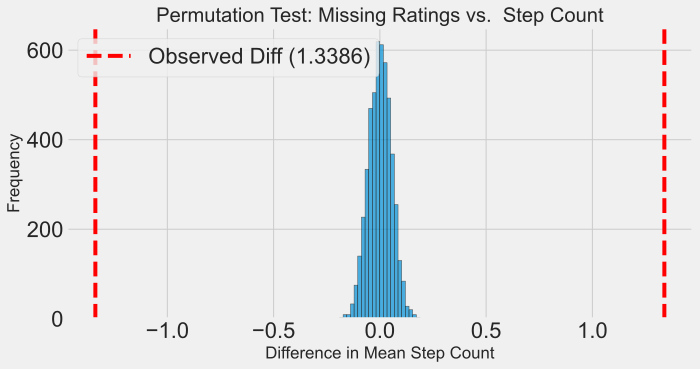

In [91]:
plt.style.use('fivethirtyeight')

# Step 1: Create a binary column for missingness
eda_recipes['rating_missing'] = eda_recipes['rating'].isna()

# Step 2: Compute observed difference in mean prep_time
obs_diff = eda_recipes.groupby('rating_missing')['n_steps'].mean().diff().iloc[-1]

# Step 3: Define permutation test function
def permutation_test(data, group_col, value_col, n_permutations=5000):
    observed_diff = data.groupby(group_col)[value_col].mean().diff().iloc[-1]
    perm_diffs = []

    for _ in range(n_permutations):
        shuffled_labels = np.random.permutation(data[group_col])
        permuted_diff = data.assign(shuffled_label=shuffled_labels).groupby('shuffled_label')[value_col].mean().diff().iloc[-1]
        perm_diffs.append(permuted_diff)

    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    return observed_diff, perm_diffs, p_value

# Step 4: Run permutation test
obs_diff, perm_diffs, p_value = permutation_test(eda_recipes, 'rating_missing', 'n_steps')

# Step 5: Print results
print(f"Observed Difference in Mean Step Count: {obs_diff:.4f}")
print(f"P-value: {p_value:.4f}")

# Step 6: Plot the permutation distribution
plt.hist(perm_diffs, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(obs_diff, color='red', linestyle='dashed', label=f'Observed Diff ({obs_diff:.4f})')
plt.axvline(-obs_diff, color='red', linestyle='dashed')
plt.xlabel('Difference in Mean Step Count')
plt.ylabel('Frequency')
plt.title('Permutation Test: Missing Ratings vs. Step Count')
plt.legend()
plt.show()


Lets look at the kde plots:

In [127]:
# Step 1: Remove rows where 'n_steps' is NaN or infinite
eda_recipes_clean = eda_recipes.dropna(subset=['n_steps'])
eda_recipes_clean = eda_recipes_clean[np.isfinite(eda_recipes_clean['n_steps'])]

# Step 2: Ensure 'rating_missing' is correctly assigned
eda_recipes_clean['rating_missing'] = eda_recipes_clean['rating'].isna().map({
    True: 'Missing',
    False: 'Not Missing'
})

# Step 3: Store original KDE plot
fig_original = create_kde_plotly(
    df=eda_recipes_clean,
    group_col='rating_missing',
    group1='Missing',
    group2='Not Missing',
    vals_col='n_steps',
    title="Original Density of n_steps by Missingness of Rating"
)

fig_original.show()

# Step 4: Perform one permutation by shuffling 'rating_missing' labels
shuffled_labels = np.random.permutation(eda_recipes_clean['rating_missing'])
eda_recipes_permuted = eda_recipes_clean.copy()
eda_recipes_permuted['rating_missing'] = shuffled_labels  # Assign shuffled labels

# Step 5: Create KDE plot for permuted data
fig_permuted = create_kde_plotly(
    df=eda_recipes_permuted,
    group_col='rating_missing',
    group1='Missing',
    group2='Not Missing',
    vals_col='n_steps',
    title="Permuted Density of n_steps by Missingness of Rating"
)

fig_permuted.show()



It appears that the missingness of rating may be dependent on the number of steps in a recipe! This could be due to many reasons. If we consider the fact that these are users who *did* leave a review, but *didn't* leave a rating, the true reason for this relationship is harder to track down. Users may feel that they didn't do the long and complex recipe justice, and therefore be reluctant to leave a rating because they don't trust their judgement. Or perhaps they had a higher expectation of the complex recipe, and were reluctant to show that it didn't turn out as well as they had hoped.

Lets take a look at the relationship between missing rating vs minutes to see if we find the same relationship.

Observed Difference in Mean minutes: 51.4524
P-value: 0.1160


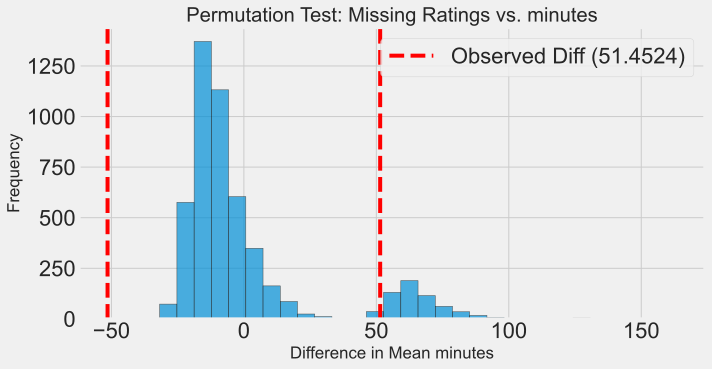

In [124]:
# Compute observed difference in minutes
obs_diff = recipes.groupby('rating_missing')['minutes'].mean().diff().iloc[-1]

# Run permutation test
obs_diff, perm_diffs, p_value = permutation_test(eda_recipes, 'rating_missing', 'minutes')

# Print results
print(f"Observed Difference in Mean minutes: {obs_diff:.4f}")
print(f"P-value: {p_value:.4f}")

# Plot the permutation distribution
plt.hist(perm_diffs, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(obs_diff, color='red', linestyle='dashed', label=f'Observed Diff ({obs_diff:.4f})')
plt.axvline(-obs_diff, color='red', linestyle='dashed')
plt.xlabel('Difference in Mean minutes')
plt.ylabel('Frequency')
plt.title('Permutation Test: Missing Ratings vs. minutes')
plt.legend()
plt.show()

In [125]:
eda_recipes_clean = eda_recipes[eda_recipes['minutes'] < 100]

# Step 2: Ensure 'rating_missing' is correctly assigned
eda_recipes_clean['rating_missing'] = eda_recipes_clean['rating'].isna().map({
    True: 'Missing',
    False: 'Not Missing'
})

# Step 3: Store original KDE plot
fig_original = create_kde_plotly(
    df=eda_recipes_clean,
    group_col='rating_missing',
    group1='Missing',
    group2='Not Missing',
    vals_col='minutes',
    title="Original Density of minutes by Missingness of Rating"
)

fig_original.show()

# Step 4: Perform one permutation by shuffling 'rating_missing' labels
shuffled_labels = np.random.permutation(eda_recipes_clean['rating_missing'])
eda_recipes_permuted = eda_recipes_clean.copy()
eda_recipes_permuted['rating_missing'] = shuffled_labels  # Assign shuffled labels

# Step 5: Create KDE plot for permuted data
fig_permuted = create_kde_plotly(
    df=eda_recipes_permuted,
    group_col='rating_missing',
    group1='Missing',
    group2='Not Missing',
    vals_col='minutes',
    title="Permuted Density of minutes by Missingness of Rating"
)

fig_permuted.show()

Although this relationship looks similar, it looks like its not statistically significant with a p-val of 0.11.

In conclusion, it appears that the missingness of rating is a combination of MAR (dependent on the 'n_steps' column) and NMAR, but unfortunately we can't prove this statement.

## Step 4: Hypothesis Testing

Before we begin our hypothesis test, we will first define what we call a balance score. The balance score is a rating that we give each recipe based on its balance between time to cook, taste, and nutritional profile. We will using recipe rating as a proxy for taste.

We will manually define a formula to calculate this balance score, which returns scores from 1-10, with 10 being the most healthy, easy to cook, and protein dense meals, and 1 being unhealthy, hard to cook, and less nutritional meals.

This score is mostly subjective, as we are setting the weights ourselves. This is okay though, because our goal is to plug in our own recipes, and find out if its a recipe we would like to cook.

In [ ]:
hypothesis_recipes = recipes_copy.copy()

In [167]:
# Step 1: Bin the avg_rating column
hypothesis_recipes['rating_category'] = pd.cut(
    hypothesis_recipes['avg_rating'], bins=[1, 4.6, 4.99, 5], labels=["Low", "Medium", "High"], include_lowest=True
)

# Step 2: One-hot encode the rating category column
rating_dummies = pd.get_dummies(hypothesis_recipes['rating_category'], prefix='rating')

# Merge one-hot encoded columns with the main DataFrame
hypothesis_recipes = pd.concat([hypothesis_recipes, rating_dummies], axis=1)

Here we decide our weights, and calculate balance scores, with each weight having a logarithmic decay as to not score certain meals too low or too high.

In [ ]:
# Define Weights
W_RATING_HIGH = 0.4
W_RATING_MEDIUM = 0.2
W_RATING_LOW = 0.0
W_TIME = -0.01    # Penalizes long cooking times
W_N_STEPS = -0.06  # Penalizes overly complex recipes
W_SAT_FAT = -0.06  # Less saturated fat is better
W_CALORIES = -0.01  # Penalizes excessive calories
W_PROTEIN = 0.2  # More protein is better
W_CARBS = -0.01  # Too many carbs reduce balance
W_SUGAR = -0.04  # Excess sugar is penalized
W_SODIUM = -0.03  # Excess sodium is penalized

T = 60  # Scaling factor for cooking time penalty

# Logarithmic Decay Function
def log_decay(x, max_val):
    """Applies logarithmic decay to prevent outliers from dominating."""
    return np.log1p(x) / np.log1p(max_val) if max_val > 0 else 0

# Compute max values for normalization
max_values = {
    'minutes': hypothesis_recipes['minutes'].max(),
    'n_steps': hypothesis_recipes['n_steps'].max(),
    'sat_fat': hypothesis_recipes['sat_fat'].max(),
    'calories': hypothesis_recipes['calories'].max(),
    'protein': hypothesis_recipes['protein'].max(),
    'carbs': hypothesis_recipes['carbs'].max(),
    'sugar': hypothesis_recipes['sugar'].max(),
    'sodium': hypothesis_recipes['sodium'].max()
}

def calculate_balance_score(row):
    """
    Computes the balance score for a single recipe row, applying logarithmic decay to prevent outliers.
    """
    # One-hot encoded rating impact
    rating_high = row.get('rating_High', 0) * W_RATING_HIGH
    rating_medium = row.get('rating_Medium', 0) * W_RATING_MEDIUM
    rating_low = row.get('rating_Low', 0) * W_RATING_LOW

    # Compute log-decayed time factor (exponential decay still applied)
    time_factor = np.exp(-row['minutes'] / T) if row['minutes'] > 0 else 1
    time_factor = log_decay(time_factor, max_values['minutes'])

    # Compute final balance score as a weighted sum of log-decayed factors
    balance_score = (
        rating_high + rating_medium + rating_low + 
        (W_TIME * time_factor) + 
        (W_N_STEPS * log_decay(row['n_steps'], max_values['n_steps'])) +
        (W_SAT_FAT * log_decay(row['sat_fat'], max_values['sat_fat'])) +
        (W_CALORIES * log_decay(row['calories'], max_values['calories'])) +
        (W_PROTEIN * log_decay(row['protein'], max_values['protein'])) +
        (W_CARBS * log_decay(row['carbs'], max_values['carbs'])) +
        (W_SUGAR * log_decay(row['sugar'], max_values['sugar'])) +
        (W_SODIUM * log_decay(row['sodium'], max_values['sodium']))
    )
    
    return balance_score

# Apply the function to compute balance scores
hypothesis_recipes['balance_score'] = hypothesis_recipes.apply(calculate_balance_score, axis=1)

# Rescale balance score to 0-10 range using Min-Max Scaling
min_score = hypothesis_recipes['balance_score'].min()
max_score = hypothesis_recipes['balance_score'].max()
hypothesis_recipes['balance_score'] = 10 * (hypothesis_recipes['balance_score'] - min_score) / (max_score - min_score)
hypothesis_recipes.head(5)

,name,minutes,tags,n_steps,...,rating_Low,rating_Medium,rating_High,balance_score
id,,,,,,,,,
333281,1 brownies in the world best ever,40,"[60-minutes-or-less, time-to-make, course, mai...",10,...,True,False,False,1.54
453467,1 in canada chocolate chip cookies,45,"[60-minutes-or-less, time-to-make, cuisine, pr...",12,...,False,False,True,8.26
306168,412 broccoli casserole,40,"[60-minutes-or-less, time-to-make, course, mai...",6,...,False,False,True,8.88
286009,millionaire pound cake,120,"[time-to-make, course, cuisine, preparation, o...",7,...,False,False,True,8.41
475785,2000 meatloaf,90,"[time-to-make, course, main-ingredient, prepar...",17,...,False,False,True,8.76


In [ ]:
hypothesis_recipes['balance_score'].describe()

count   83782.00
mean        6.19
std         3.06
min         0.00
25%         2.44
50%         8.22
75%         8.80
max        10.00
Name: balance_score_scaled, dtype: float64

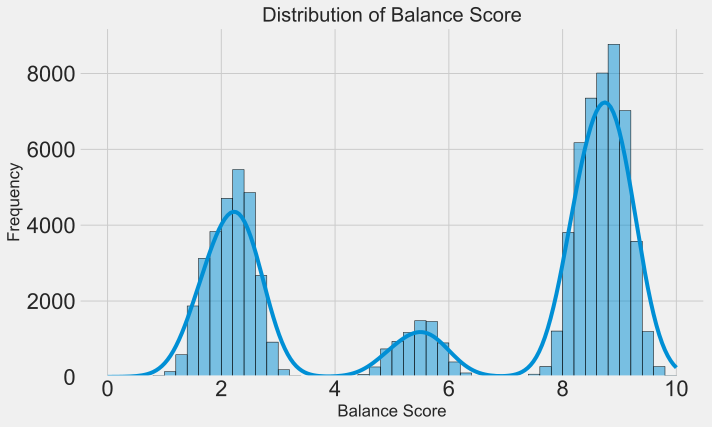

In [ ]:
# Plot distribution of balance scores
plt.figure(figsize=(10, 6))

# Histogram + KDE for smooth density estimate
sns.histplot(hypothesis_recipes['balance_score_scaled'], bins=50, kde=True, edgecolor='black')

# Labels and title
plt.xlabel("Balance Score")
plt.ylabel("Frequency")
plt.title("Distribution of Balance Score")

# Show the plot
plt.show()

#### Hypothesis Test:

- Null Hypothesis ($H_{0}$): 

There is no significant correlation between human calculated balance scores based off intuition and the algorithmically calculated balance scores. 

$H_{0}$ : $p = 0$

(Where $p$ represents the correlation coefficient between human human balance scores and algorithm balance scores.)

- Alternative Hypothesis ($H_{A}$):

​
There is a significant correlation between human calculated balance scores based off intuition and the algorithmically calculated balance scores. 

$H_{0}$ : $p ≠ 0$

Here are the human calculated balance scores for 30 randomly sampled recipes:

In [154]:
manual_scores = {333281:3, 453467:4, 306168:8, 286009:3, 475785:6, 500166:3, 501028:9, 503475:5, 522861:3,
       333797:10, 428056:4, 306245:7, 523359:4, 495314:7, 327356:8, 325509:9,
       445026:6, 310570:1, 318677:10, 317508:5, 474769:1, 316470:8, 343338:9, 311991:7, 336744:3,
       303457:7, 353044:1, 293225:2, 303460:5, 345123:9}


=== Hypothesis Test Results ===
Observed Pearson Correlation: 0.511
Permutation Test P-Value: 0.0048


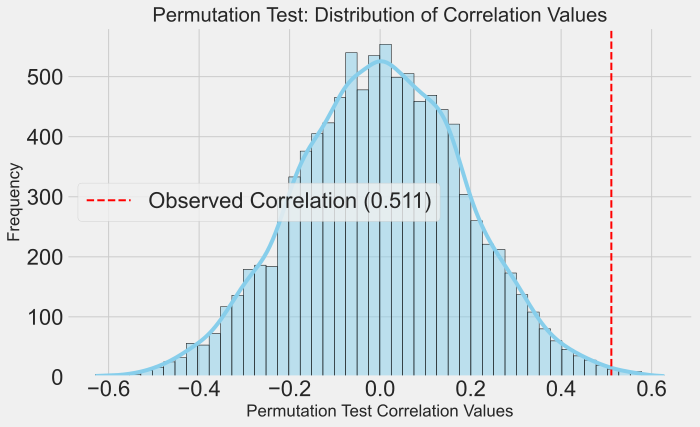

In [ ]:
# Step 1: Manually assign balance scores to 30 random recipes
# Create a dictionary of manually assigned scores for selected recipe IDs
manual_scores = {333281:3, 453467:4, 306168:8, 286009:3, 475785:6, 500166:3, 501028:9, 503475:5, 522861:3,
       333797:10, 428056:4, 306245:7, 523359:4, 495314:7, 327356:8, 325509:9,
       445026:6, 310570:1, 318677:10, 317508:5, 474769:1, 316470:8, 343338:9, 311991:7, 336744:3,
       303457:7, 353044:1, 293225:2, 303460:5, 345123:9}
    
# Convert dictionary to DataFrame
manual_df = pd.DataFrame.from_dict(manual_scores, orient='index', columns=['manual_balance_score'])
manual_df.index.name = 'id'  # Ensure index is named "id"

# Reset index in recipes to keep 'id' as a column
recipes_reset = hypothesis_recipes.reset_index().rename(columns={'index': 'id'})

# Merge with algorithmic balance scores
comparison_df = recipes_reset[['id', 'balance_score_scaled']].merge(manual_df, on='id', how='inner')

# Step 2: Compute Pearson correlation coefficient
observed_corr, _ = pearsonr(comparison_df['balance_score_scaled'], comparison_df['manual_balance_score'])

# Step 3: Perform a permutation test
num_permutations = 10_000
perm_correlations = []

for _ in range(num_permutations):
    shuffled_scores = np.random.permutation(comparison_df['manual_balance_score'])
    perm_corr, _ = pearsonr(comparison_df['balance_score_scaled'], shuffled_scores)
    perm_correlations.append(perm_corr)

# Compute p-value
p_value = np.mean(np.abs(perm_correlations) >= np.abs(observed_corr))

# Display results
print("\n=== Hypothesis Test Results ===")
print(f"Observed Pearson Correlation: {observed_corr:.3f}")
print(f"Permutation Test P-Value: {p_value:.4f}")

# Step 4: Plot the permutation test results
plt.figure(figsize=(10, 6))

# Histogram of permuted correlations
sns.histplot(perm_correlations, bins=50, kde=True, color="skyblue", edgecolor="black")

# Vertical line for observed correlation
plt.axvline(observed_corr, color='red', linestyle='dashed', linewidth=2, label=f'Observed Correlation ({observed_corr:.3f})')

# Labels and legend
plt.xlabel("Permutation Test Correlation Values")
plt.ylabel("Frequency")
plt.title("Permutation Test: Distribution of Correlation Values")
plt.legend()
plt.show()

#### Hypothesis Test Conclusion:

We got a P-value of .0048, a Pearson's R of .511. This means we reject the null in favor of the alternative hypothesis, meaning that our formula for calculating the balance score is likely generalizable to a population with similar values of taste vs ease vs health in their cooking.

## Step 5: Framing a Prediction Problem

Ideally, we use our balance score calculator to give our own recipes a balance score. But, the balance score calculation uses the rating as a sort of proxy for taste. This means that we need find a way to predict the rating of recipes that have never been seen before if we want to find the balance score using our formula. 

Due to the lack of variance of the ratings in this dataset, we previously binned the ratings into 3 categories: Low (0-4.6 stars), Medium (4.6-4.99 stars), and High (4.99-5 stars). Using the current features present in the recipes dataset, we want to predict this rating category (low medium or high).

## Step 6: Baseline Model

Since our prediction is a trinary classification problem of a categorical variable, we have decided to use a random forest model to predict the rating category.

To start, lets see how far we can get with a base model that just uses the features already present in our data: 'minutes', 'n_steps', 'n_ingredients', 'calories', 'sat_fat', 'sugar', 'sodium', 'carbs', and 'protein'.

Note: We are intentionally leaving out the 'total_fats' column, because in our EDA we discovered that it was relatively collinear with the 'sat_fat' feature. Including collinear features in a random forest model will negatively impact performance. For this same reason, we did not include 'total_fat' in our balance score formula.

Later on we will do feature engineering, k fold cross validation, and other techniques when deciding on a final model, but this should be sufficient for now.

In [25]:
# Starting with a clean copy of recipes dataframe
recipes = recipes_copy.copy()

In [26]:
# Create rating categories safely
recipes['rating_category'] = pd.cut(
    recipes['avg_rating'], bins=[1, 4.6, 4.99, 5], labels=["Low", "Medium", "High"], include_lowest=True
)

# Define Features & Target
numeric_features = ['minutes', 'n_steps', 'n_ingredients', 'calories', 'sugar', 'carbs', 'sat_fat', 'sodium', 'protein']
target = 'rating_category'

# Drop rows with NaN in the target variable
recipes = recipes.dropna(subset=[target])

In [27]:
modeling_recipes = recipes.copy()

In [ ]:
# Create Pipeline
model_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=10))
])

# Split Data
X = modeling_recipes[numeric_features]
y = modeling_recipes[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Train the Model
model_pipeline.fit(X_train, y_train)

# Predict & Evaluate
y_pred = model_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {accuracy:.2f}")

# Display Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Classification Accuracy: 0.57

Classification Report:
              precision    recall  f1-score   support

        High       0.59      0.92      0.72      9550
         Low       0.37      0.10      0.15      5167
      Medium       0.18      0.00      0.00      1518

    accuracy                           0.57     16235
   macro avg       0.38      0.34      0.29     16235
weighted avg       0.48      0.57      0.47     16235



Here we have created a simple single step SKLearn pipeline which contains the Random Forest Classifier model. This way, going forward, we can build upon this with different transformations and preprocessing steps. 

We have used a forest with 100 trees to start. Since this dataset contains 81000 rows, it is computationaly costly as we scale the number of trees.

Now, considering our findings in the EDA section, specifically the low correlation between our features and rating, our model accuracy of 0.57 is actually not bad.

If the model were to predict entirely at random, it would perform with an accuracy of approximately 0.33 or 33%. An accuracy of 0.57 shows that our model is performing much better than assigning rating categories at random. This is goo

In [227]:
model_pipeline

Pipeline(steps=[('classifier', RandomForestClassifier(random_state=10))])

## Step 7: Final Model

Lets start with implementing new features:

### Feature Engineering:

Before we begin feature engineering, we need to find a way to rate the effectiveness of our features. To do this, we will use an ANOVA F-Test.

The Analysis of Variance (ANOVA) F-test is used to determine if there is a statistically significant difference between the means of multiple groups. In our case, it will help us evaluate whether a feature is effective in distinguishing between our 3 different categorical classes of low high and medium.

For each feature, we will calculate an F score: $F = \frac {Variance Within Groups}{Variance Between Groups}$

Here is an example using our base features:

In [ ]:
# Define Features & Target
numeric_features = ['minutes', 'n_steps', 'n_ingredients', 'calories', 'sugar', 'sodium', 'carbs', 'sat_fat', 'protein']
target = 'rating_category'


# Extract Features and Target
X = modeling_recipes[numeric_features]  # Numerical Features
y = modeling_recipes[target]  # Target variable

# Perform ANOVA F-test
f_scores, p_values = f_classif(X, y)

# Create DataFrame of Results
anova_results = pd.DataFrame({
    'Feature': numeric_features,
    'F-Score': f_scores,
    'p-value': p_values
}).sort_values(by='F-Score', ascending=False)

# Display the results
print("\nANOVA F-Test Results:")
print(anova_results)



ANOVA F-Test Results:
         Feature  F-Score  p-value
1        n_steps    63.09     0.00
7        sat_fat    20.33     0.00
3       calories    17.30     0.00
4          sugar    16.41     0.00
8        protein    15.88     0.00
2  n_ingredients    12.75     0.00
6          carbs     9.36     0.00
5         sodium     1.87     0.15
0        minutes     0.51     0.60


Here we can see that n_steps and sat_fat are the largest differentiators between our 3 categories.

#### Creating Features:

Now, want to look for any quadratic, squared, or logarithmic relationships within our base quantitative variables that may help us predict the rating bin of a recipe. These extra features may be useful to increase the accuracy of our random forest model.

In [ ]:
from itertools import combinations

# Function to create quadratic interaction features
def create_quadratics(df):
    """Generate quadratic interaction terms for numerical columns, excluding 'rating' and 'avg_rating'."""
    
    # Select only numerical columns, excluding 'rating', 'avg_rating', and 'total_fat'
    excluded_cols = {'rating', 'avg_rating', 'total_fat'}
    quantitative_columns = [col for col in df.select_dtypes(include=['number']).columns if col not in excluded_cols]

    # Ensure all numeric columns are actually numeric
    df = df.copy()
    for col in quantitative_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert non-numeric to NaN

    # Fill missing values with median
    df[quantitative_columns] = df[quantitative_columns].apply(lambda col: col.fillna(col.median()))

    # Store quadratic features in a dictionary to avoid DataFrame fragmentation
    quadratic_features_dict = {}

    # Generate only quadratic (two-variable) interactions
    for col1, col2 in combinations(quantitative_columns, 2):
        quadratic_features_dict[f'{col1} * {col2}'] = df[col1] * df[col2]

    # Convert dictionary to DataFrame and concatenate at once
    quadratic_df = pd.DataFrame(quadratic_features_dict, index=df.index)

    # Fill NaNs in new quadratic features
    quadratic_df = quadratic_df.fillna(0)
    
    return quadratic_df

# Create quadratic features
quadratic_features = create_quadratics(modeling_recipes)

# Merge quadratic features with original dataset
modeling_recipes = pd.concat([modeling_recipes, quadratic_features], axis=1)

# Define Features & Target
numeric_features = list(quadratic_features.columns)  # Use only quadratic features
target = 'rating_category'

# Extract Features and Target
X = modeling_recipes[numeric_features]  # Quadratic Features
y = modeling_recipes[target]  # Target variable

# Perform ANOVA F-test
f_scores, p_values = f_classif(X, y)

# Create DataFrame of Results
anova_results = pd.DataFrame({
    'Feature': numeric_features,
    'F-Score': f_scores,
    'p-value': p_values
}).sort_values(by='F-Score', ascending=False)

# Display the results
print("\nANOVA F-Test Results:")
print(anova_results.head(5))

Using 9 numeric columns for quadratic feature creation.

ANOVA F-Test Results:
                     Feature  F-Score  p-value
8    n_steps * n_ingredients    47.43     0.00
19   n_ingredients * sat_fat    20.49     0.00
13         n_steps * sat_fat    16.76     0.00
9         n_steps * calories    16.48     0.00
15  n_ingredients * calories    15.85     0.00


These are the top 5 quadtratic features in terms of $F$. It looks like n_steps * n_ingredients might be a good candidate to include in our final model.

Lets try log transformations and square transformations on our quantitative columns next:

In [28]:
modeling_recipes = recipes_copy.copy()

In [29]:
# Function to apply transformations (log or squared)
def apply_transformations(df, transformation):
    """Apply specified transformation ('log' or 'squared') to numerical columns, excluding 'rating' and 'avg_rating'."""
    
    # Select only numerical (quantitative) columns, excluding 'rating', 'avg_rating', and 'total_fat'
    excluded_cols = {'rating', 'avg_rating', 'total_fat'}
    quantitative_columns = [col for col in df.select_dtypes(include=['number']).columns if col not in excluded_cols]

    print(f"Applying {transformation} transformation to {len(quantitative_columns)} numeric columns.")

    # Ensure all numeric columns are actually numeric
    df = df.copy()
    for col in quantitative_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert non-numeric to NaN

    # Fill missing values with median
    df[quantitative_columns] = df[quantitative_columns].apply(lambda col: col.fillna(col.median()))

    # Apply the specified transformation
    transformed_features = {}
    
    for col in quantitative_columns:
        if transformation == "log":
            transformed_features[f'log({col})'] = np.log1p(df[col])  # log(1 + x) to handle zeros
        elif transformation == "squared":
            transformed_features[f'squared({col})'] = df[col] ** 2  # Squared transformation

    # Convert dictionary to DataFrame
    transformed_df = pd.DataFrame(transformed_features, index=df.index)

    return transformed_df

In [31]:
# Apply log transformation
log_features = apply_transformations(recipes, transformation="log")

# Merge with the main recipes DataFrame
recipes_log = pd.concat([recipes, log_features], axis=1)

# Perform ANOVA F-test on log-transformed features
X_log = log_features
y = recipes['rating_category']  # Target variable

f_scores_log, p_values_log = f_classif(X_log, y)

anova_results_log = pd.DataFrame({
    'Feature': X_log.columns,
    'F-Score': f_scores_log,
    'p-value': p_values_log
}).sort_values(by='F-Score', ascending=False)

print("\nANOVA F-Test Results for Log-Transformed Features:")
print(anova_results_log)

Applying log transformation to 9 numeric columns.

ANOVA F-Test Results for Log-Transformed Features:
              Feature  F-Score  p-value
6        log(protein)    92.02     0.00
0        log(minutes)    68.40     0.00
4          log(sugar)    49.94     0.00
1        log(n_steps)    39.76     0.00
8          log(carbs)    38.08     0.00
5         log(sodium)    29.61     0.00
3       log(calories)    23.29     0.00
2  log(n_ingredients)    20.29     0.00
7        log(sat_fat)     3.39     0.03


We've got some good results here. It looks like the log of protein should be highly effective in distinguishing between the 3 rating categories. The log of minutes looks like a strong candidate as well with an F-Score of 68.40.

In [32]:
# Apply squared transformation
squared_features = apply_transformations(recipes, transformation="squared")

# Merge with the main recipes DataFrame
recipes_squared = pd.concat([recipes, squared_features], axis=1)

# Perform ANOVA F-test on squared features
X_squared = squared_features
y = recipes['rating_category']  # Target variable

f_scores_squared, p_values_squared = f_classif(X_squared, y)

anova_results_squared = pd.DataFrame({
    'Feature': X_squared.columns,
    'F-Score': f_scores_squared,
    'p-value': p_values_squared
}).sort_values(by='F-Score', ascending=False)

print("\nANOVA F-Test Results for Squared Features:")
print(anova_results_squared)

Applying squared transformation to 9 numeric columns.

ANOVA F-Test Results for Squared Features:
                  Feature  F-Score  p-value
1        squared(n_steps)    56.86     0.00
2  squared(n_ingredients)     8.80     0.00
3       squared(calories)     4.09     0.02
7        squared(sat_fat)     2.13     0.12
6        squared(protein)     1.41     0.25
8          squared(carbs)     0.99     0.37
5         squared(sodium)     0.93     0.40
4          squared(sugar)     0.78     0.46
0        squared(minutes)     0.32     0.73


Number of steps squared looks like a strong candidate too. 

#### Choosing Features:

Now, with all of these features, which ones do we use in our final model? 

Well there are some things to consider:

1. Adding a relevant and important feature can decrease model bias, with a only a small increase in variance. This is good!
2. Adding a redundant feature doesn't effect bias, and only increases variance. This is bad for generalization. We should avoid this. 
3. Adding an irrelevant feature greatly increases variance, with no effect on bias. This causes overfitting. We should also avoid this.
4. Adding too many features can cause overfitting.

We are working with a fairly large dataset containing 81000 recipes, which should help to mitigate these effects since there are enough data points to define patterns across all feature dimensions. Basically the model has plenty of training data, so we can add many features.

Here, I've selected the the top 17 features in terms of their F-Scores: 

    squared(n_steps), log(protein), log(minutes), log(sugar), log(n_steps), log(carbs), log(sodium), log(calories), log(n_ingredients), log(sat_fat),
    n_steps * n_ingredients, n_ingredients * sat_fat, n_steps * sat_fat, n_steps, sat_fat, calories, and sugar


Instead of removing features by hand, we can use recursive feature elimination, which will naturally root out these unwanted/redundant features. Luckily for us, this is easily implemented using SKLearn. For each recursion, this method removes the least imporant feature within its decision making process.

In [33]:
# ===================================
# Recursive Feature Elimination (RFE)
# ===================================
modeling_recipes = recipes.copy()

# Ensure original numeric columns exist before transformations
required_numeric_columns = ['n_steps', 'n_ingredients', 'sat_fat', 'calories', 'sugar', 'protein', 'minutes', 'sodium', 'carbs']

# Step 1: Compute Log-Transformed Features (log(1 + x) to avoid log(0))
modeling_recipes["log(protein)"] = np.log1p(modeling_recipes["protein"])
modeling_recipes["log(minutes)"] = np.log1p(modeling_recipes["minutes"])
modeling_recipes["log(sugar)"] = np.log1p(modeling_recipes["sugar"])
modeling_recipes["log(n_steps)"] = np.log1p(modeling_recipes["n_steps"])
modeling_recipes["log(carbs)"] = np.log1p(modeling_recipes["carbs"])
modeling_recipes["log(sodium)"] = np.log1p(modeling_recipes["sodium"])
modeling_recipes["log(calories)"] = np.log1p(modeling_recipes["calories"])
modeling_recipes["log(n_ingredients)"] = np.log1p(modeling_recipes["n_ingredients"])
modeling_recipes["log(sat_fat)"] = np.log1p(modeling_recipes["sat_fat"])

# Step 2: Compute Squared Feature
modeling_recipes["squared(n_steps)"] = modeling_recipes["n_steps"] ** 2

# Step 3: Compute Interaction Terms
modeling_recipes["n_steps * n_ingredients"] = modeling_recipes["n_steps"] * modeling_recipes["n_ingredients"]
modeling_recipes["n_ingredients * sat_fat"] = modeling_recipes["n_ingredients"] * modeling_recipes["sat_fat"]
modeling_recipes["n_steps * sat_fat"] = modeling_recipes["n_steps"] * modeling_recipes["sat_fat"]

# Step 4: Define Selected Features
selected_features = [
    "squared(n_steps)", "log(protein)", "log(minutes)", "log(sugar)", "log(n_steps)", 
    "log(carbs)", "log(sodium)", "log(calories)", "log(n_ingredients)", "log(sat_fat)",
    "n_steps * n_ingredients", "n_ingredients * sat_fat", "n_steps * sat_fat",
    "n_steps", "sat_fat", "calories", "sugar"
]

# Split Data
X = modeling_recipes[selected_features]
y = modeling_recipes[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=10)
rf.fit(X_train, y_train)  

# Perform RFE to select top 10 features
rfe = RFE(rf, n_features_to_select=10)
rfe.fit(X_train, y_train)

# Extract Selected Features
best_features = X_train.columns[rfe.support_]
print("Top 10 Selected Features Using RFE:", best_features.tolist())

# Display Feature Importance of Selected Features
feature_importance_df = pd.DataFrame({
    "Feature": best_features,
    "Importance": rf.feature_importances_[rfe.support_]
}).sort_values(by="Importance", ascending=False)

Top 10 Selected Features Using RFE: ['log(protein)', 'log(minutes)', 'log(sugar)', 'log(sodium)', 'log(calories)', 'n_steps * n_ingredients', 'n_ingredients * sat_fat', 'n_steps * sat_fat', 'calories', 'sugar']


Lets see if using these features have any effect on our model performance:

In [34]:
# Define Selected Features After RFE
final_selected_features = best_features.tolist()

# Split Data Using Only Selected Features
X = modeling_recipes[final_selected_features]
y = modeling_recipes[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Train a New Random Forest Model
rf_final = RandomForestClassifier(n_estimators=100, random_state=10)
rf_final.fit(X_train, y_train)

# Make Predictions
y_pred = rf_final.predict(X_test)

# Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Final Model Accuracy Using RFE Selected Features: {accuracy:.2f}")

# Display Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Final Model Accuracy Using RFE Selected Features: 0.57

Classification Report:
              precision    recall  f1-score   support

        High       0.59      0.92      0.72      9537
         Low       0.34      0.09      0.14      5237
      Medium       0.00      0.00      0.00      1461

    accuracy                           0.57     16235
   macro avg       0.31      0.34      0.29     16235
weighted avg       0.46      0.57      0.47     16235



#### Feature Engineering Conclusion:

We can see that these new features not produce a significant increase in performance.


This suggests that:

The new features are not providing additional discriminative power.

Random Forest is already extracting useful patterns from the original data, meaning the transformations aren't making a meaningful difference.

The dataset might be limited by other constraints, which in this case is likely the insufficient predictive power of available base features.


#### Implementing k-fold cross validation, hyperparameter optimization, and feature subsetting, and bootstrapping:

Using SKLearns Grid Search CV, we can try many combinations of hyperparameters and compare their performance. Here we will test different hyperparameters for: # of trees, min samples split (# of samples in a node required to split), and min samples leaf (how small a leaf node can be). This also uses k-fold cross validation with the 'cv' argument to ensure our results are generalizable to unseen data. 

We can also use feature subetting, where, for each tree, we select a random subset of features that the tree will use to make decisions. This prevents the tree from relying too much on strong predictors, and increases the diversity among trees.

We can also use bootstrapping, or Bagging as its called, to make sure each tree is trained on a random sample. This also improves variance among trees, which leads to better generalization.

In [35]:
# Best features
final_selected_features = best_features.tolist()

# Define Feature Matrix and Target Variable
X = modeling_recipes[final_selected_features]
y = modeling_recipes[target]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Define Hyperparameter Grid
param_grid = {
    'classifier__n_estimators': [200, 300],  # Number of trees
    'classifier__max_features': ['sqrt'],  # Feature subsetting
    'classifier__bootstrap': [True],  # Bootstrapping enabled
    'classifier__random_state': [10],  # Fixed seed for reproducibility
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Create the Full Pipeline
model_pipeline = Pipeline([
    ('classifier', RandomForestClassifier())
])

# Perform Grid Search Cross-Validation
grid_search = GridSearchCV(model_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best Model from Grid Search
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate with Cross-Validation
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy: {np.mean(cv_scores):.2f} (+/- {np.std(cv_scores):.2f})")

# Predict on Test Set
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Classification Accuracy: {accuracy:.2f}")

# Display Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'classifier__bootstrap': True, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300, 'classifier__random_state': 10}
Cross-Validation Accuracy: 0.58 (+/- 0.00)
Test Set Classification Accuracy: 0.58

Classification Report:
              precision    recall  f1-score   support

        High       0.59      0.97      0.73      9550
         Low       0.39      0.05      0.08      5167
      Medium       0.00      0.00      0.00      1518

    accuracy                           0.58     16235
   macro avg       0.33      0.34      0.27     16235
weighted avg       0.47      0.58      0.46     16235



/opt/anaconda3/envs/dsc80/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/envs/dsc80/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/envs/dsc80/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Best features: 

#### Creating our final model:

In [ ]:
# Define Feature Engineering Function
def log_transform(X):
    return np.log1p(X)

# Define Selected Features
selected_features = ['protein', 'minutes', 'sugar', 'sodium', 'calories',
                     'n_steps', 'n_ingredients', 'sat_fat']

derived_features = [
    ('log_protein', 'protein'),
    ('log_minutes', 'minutes'),
    ('log_sugar', 'sugar'),
    ('log_sodium', 'sodium'),
    ('log_calories', 'calories')
]

interaction_features = [
    ('n_steps_n_ingredients', lambda df: df['n_steps'] * df['n_ingredients']),
    ('n_ingredients_sat_fat', lambda df: df['n_ingredients'] * df['sat_fat']),
    ('n_steps_sat_fat', lambda df: df['n_steps'] * df['sat_fat'])
]

# Create Feature Transformation Pipeline
transformers = []

# Log Transform Features
for name, feature in derived_features:
    transformers.append((name, FunctionTransformer(log_transform), [feature]))

# Interaction Features
for name, func in interaction_features:
    transformers.append((name, FunctionTransformer(func, validate=False), selected_features))

# Include Original Features
original_features = ['calories', 'sugar']
transformers.append(('passthrough', 'passthrough', original_features))

# Define Column Transformer
preprocessor = ColumnTransformer(transformers)

# Define Model Pipeline
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_features='sqrt',
                                          bootstrap=True, random_state=10))
])

# Define Feature Matrix and Target Variable
X = recipes[selected_features]
y = recipes['target']

# Perform 3-Fold Cross-Validation
cv_scores = cross_val_score(model_pipeline, X, y, cv=3, scoring='accuracy')
print(f"Cross-Validation Accuracy: {np.mean(cv_scores):.2f} (+/- {np.std(cv_scores):.2f})")

# Train Final Model on Full Training Data
model_pipeline.fit(X, y)

# Predict on Training Data
y_pred = model_pipeline.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Final Model Training Accuracy: {accuracy:.2f}")

# Display Classification Report
print("\nClassification Report:")
print(classification_report(y, y_pred))


Final Model Trained on all data:

## Step 8: Fairness Analysis

To check if our model performs worse for individuals in one group than the others, we can compare the precision of the predictions between these groups. We will use a permutation test to see if our observed differences between precision is significant or not.

In [ ]:
# Function to Calculate Demographic Parity for Rating Categories
def demographic_parity(y_true, y_pred, rating_category):
    """
    Calculate Demographic Parity for different rating categories.
    """
    rating_category = rating_category.loc[y_true.index]  # Ensure alignment with y_true
    
    if len(y_pred) != len(rating_category):
        print(f"Length of y_pred: {len(y_pred)}")
        print(f"Length of rating_category: {len(rating_category)}")
        raise ValueError("Mismatch in length between y_pred and rating_category")
    
    categories = np.unique(rating_category)
    probabilities = {}
    
    for category in categories:
        mask = rating_category == category
        if np.sum(mask) > 0:
            probabilities[category] = np.mean(y_pred[mask] == 1)  # Calculate fraction of 'positive' predictions
    
    return probabilities

# Example Usage
rating_category = recipes['rating_category'].loc[y.index]  # Ensure only trained samples are used
demographic_parity_results = demographic_parity(y, y_pred, rating_category)

print("\nDemographic Parity:")
print(demographic_parity_results)

Length of y_pred: 16235
Length of rating_category: 81173


ValueError: Mismatch in length between y_pred and rating_category

In [ ]:
def precision_by_group(y_true, y_pred, rating_category):
    """
    Calculate precision for different rating categories.
    Precision = True Positives / (True Positives + False Positives)
    """
    rating_category = rating_category.loc[y_true.index]  # Ensure alignment
    
    if len(y_pred) != len(rating_category):
        raise ValueError("Mismatch in length between y_pred and rating_category")
    
    categories = np.unique(rating_category)
    precision_scores = {}

    for category in categories:
        mask = rating_category == category
        if np.sum(mask) > 0:
            true_positives = np.sum((y_true[mask] == 1) & (y_pred[mask] == 1))
            predicted_positives = np.sum(y_pred[mask] == 1)
            precision_scores[category] = true_positives / predicted_positives if predicted_positives > 0 else 0
    
    return precision_scores

# Example Usage
rating_category = recipes['rating_category'].loc[y.index]  # Ensure only trained samples are used
precision_results = precision_by_group(y_test, y_pred, rating_category)
print("\nPrecision by Group:")
print(precision_results)

This will be our observed statistic: _________

- Null Hypothesis ($H_{0}$): 

The model is fair in terms of precision between groups. Any differences in precision between groups (low, medium, and high) are due to random chance rather than systematic bias.

or

$\max(\text{Precision}_{a}) - \min(\text{Precision}_{a}) \approx 0, \quad \forall a \in \{low, medium, high\}$


- Alternative Hypothesis ($H_{A}$):

The model is unfair in terms of precision across rating categories.The observed precision disparity is greater than what would be expected by chance in a randomly shuffled dataset.

or 

$\max(\text{Precision}_{a}) - \min(\text{Precision}_{a}) >$ some threshold $\delta$

Where Precision is calculated as:

$\text{Precision}_{a} = \frac{\text{True Positives in group } a}{\text{Predicted Positives in group } a}$

In [ ]:
def permutation_test_precision(y_true, y_pred, rating_category, precision_func, n_permutations=1000):
    """
    Perform a permutation test to assess fairness in precision across rating categories.

    Parameters:
    - y_true: True labels
    - y_pred: Predicted labels
    - rating_category: Group labels (e.g., 'low', 'medium', 'high')
    - precision_func: Function to calculate precision by group
    - n_permutations: Number of permutations

    Returns:
    - p-value for the observed precision differences
    """
    # Compute observed precision
    observed_precision = precision_func(y_true, y_pred, rating_category)

    # Calculate the range (max-min) of the observed precision values
    observed_range = max(observed_precision.values()) - min(observed_precision.values())

    # Perform permutation test
    permuted_ranges = []
    for _ in range(n_permutations):
        shuffled_categories = np.random.permutation(rating_category)  # Shuffle rating categories
        permuted_precision = precision_func(y_true, y_pred, shuffled_categories)
        permuted_range = max(permuted_precision.values()) - min(permuted_precision.values())
        permuted_ranges.append(permuted_range)

    # Calculate p-value
    p_value = np.mean(np.array(permuted_ranges) >= observed_range)

    return observed_precision, observed_range, permuted_ranges, p_value

# Run the updated permutation test using precision instead of demographic parity
observed_precision, observed_range, permuted_ranges, p_value = permutation_test_precision(
    y_test, y_pred, rating_category, precision_by_group, n_permutations=1000
)

# Display Results
print("\nObserved Precision by Group:")
print(observed_precision)
print(f"\nObserved Range of Precision Differences: {observed_range:.4f}")
print(f"\nPermutation Test p-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("\nThe p-value is below 0.05, so we reject the null hypothesis.")
    print("This suggests that our model exhibits precision disparities across rating categories.")
else:
    print("\nThe p-value is above 0.05, so we fail to reject the null hypothesis.")
    print("This suggests that any observed differences in precision may be due to random chance.")


#### Fairness Conclusion: